**Problem Statement and Motivation**

Define the Problem ?

We will detect safety gear on construction workers:

Classes: hardhat, vest, person

Dataset: downloaded (Kaggle) images with bounding box annotations.

This defines the object detection scenario.

In [1]:
!pip install kaggle opencv-python-headless --quiet

In [ ]:
from google.colab import files
files.upload()

In [3]:
import os
os.makedirs("/root/.kaggle", exist_ok=True)
os.rename("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)

In [4]:
!kaggle datasets download -d muhammetzahitaydn/hardhat-vest-dataset-v3 -p ./dataset --unzip

Dataset URL: https://www.kaggle.com/datasets/muhammetzahitaydn/hardhat-vest-dataset-v3
License(s): CC0-1.0
 99% 4.18G/4.21G [00:55<00:00, 148MB/s]
100% 4.21G/4.21G [00:55<00:00, 80.7MB/s]


**Dataset Description (size, classes, examples)**

In [5]:
import os

DATASET_PATH = './dataset'
print("Training images:", len(os.listdir(f"{DATASET_PATH}/images/train")))
print("Validation images:", len(os.listdir(f"{DATASET_PATH}/images/val")))
print("Test images:", len(os.listdir(f"{DATASET_PATH}/images/test")))

Training images: 17248
Validation images: 2438
Test images: 2455


**Dataset YAML generation**

In [7]:
import os

# Define the content for hardhat.yaml
DATASET_PATH = './dataset'
CLASSES = ['hardhat', 'vest', 'person']
NUM_CLASSES = len(CLASSES)

yaml_content = f"""path: {DATASET_PATH}
train: images/train
val: images/val
nc: {NUM_CLASSES}
names:
"""
for i, class_name in enumerate(CLASSES):
    yaml_content += f"  {i}: {class_name}\n"

# Define the path for the hardhat.yaml file
yaml_file_path = os.path.join(DATASET_PATH, 'hardhat.yaml')

# Write the content to the file
with open(yaml_file_path, 'w') as f:
    f.write(yaml_content)

print(f"Created hardhat.yaml at: {yaml_file_path}")
print("Content:\n" + yaml_content)


Created hardhat.yaml at: ./dataset/hardhat.yaml
Content:
path: ./dataset
train: images/train
val: images/val
nc: 3
names:
  0: hardhat
  1: vest
  2: person



In [8]:
!pip install ultralytics --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 59.5 MB/s eta 0:00:00


**Model Architecture and Training Setup**

In [9]:
from ultralytics import YOLO

# Load a pre-trained YOLOv8n model
model = YOLO('yolov8n.pt')

print("YOLOv8n model loaded successfully for fine-tuning.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8n model loaded successfully for fine-tuning.


In [10]:
results = model.train(data=yaml_file_path, epochs=10, imgsz=640, batch=16)
print("Model training initiated successfully.")

Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./dataset/hardhat.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, p

In [11]:
from ultralytics import YOLO

# Load fine-tuned model
model = YOLO("/content/runs/detect/train/weights/best.pt")  # fine-tuned weights

In [12]:
results = model.train(
    data='//content/dataset/hardhat.yaml',   # YAML file
    epochs=10,
    imgsz=640,                      # image size
    batch=16,                        # adjust according to GPU memory
    project='runs/train',            # where to save results
    name='hardhat_v8',               # folder name
    exist_ok=True                    # overwrite previous runs
)

Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=//content/dataset/hardhat.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/runs/detect/train/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=hardhat_v8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10

In [15]:
# Load your trained model (best weights)
model = YOLO("/content/runs/detect/train/weights/best.pt")
# Path to your dataset YAML file
yaml_path = "/content/dataset/hardhat.yaml"
# Check file exists
assert os.path.exists(yaml_path)

**Validation & Testing**

In [16]:
# Validate on Validation Set
metrics = model.val(data=yaml_path)
print("Validation Metrics:")
print(metrics)

Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1039.4±491.8 MB/s, size: 207.6 KB)
val: Scanning /content/dataset/labels/val.cache... 2438 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2438/2438 1.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 153/153 5.0it/s 30.6s
                   all       2438      21032      0.861      0.819       0.87      0.532
               hardhat       1782       6586      0.922       0.85      0.908      0.592
                  vest        406        870      0.787      0.746       0.82      0.537
                person        712      13576      0.874       0.86      0.882      0.466
Speed: 1.6ms preprocess, 3.8ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /content/runs/detect/val3
Validatio


image 1/1 /content/istockphoto-2117759132-612x612.jpg: 448x640 4 hardhats, 4 vests, 44.1ms
Speed: 3.0ms preprocess, 44.1ms inference, 1.6ms postprocess per image at shape (1, 3, 448, 640)


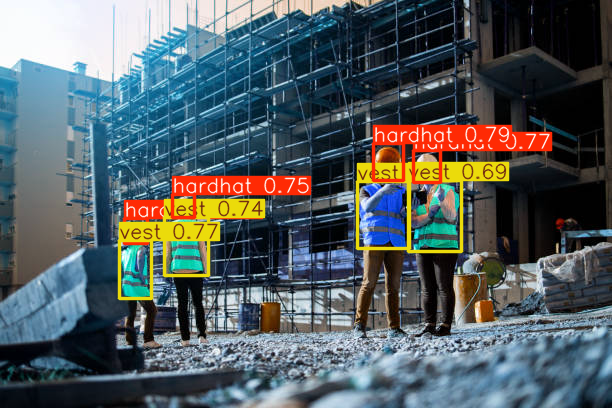

In [20]:
import cv2
from google.colab.patches import cv2_imshow

# Perform inference on the image
results = model.predict(source='/content/istockphoto-2117759132-612x612.jpg', conf=0.25)

# Display the results
for r in results:
    im_array = r.plot()
    im_rgb = cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB)
    cv2_imshow(im_rgb)

**TASK 2:**

In [12]:
model_path = "/content/runs/detect/train/weights/best.pt"
model = YOLO(model_path)
print("Model loaded successfully!")

Model loaded successfully!


In [13]:
# Run inference on unseen images
image_source = "/content/dataset/images/val"  # folder or image
results = model.predict(source=image_source, conf=0.5, save=True)
print("Prediction done! Check runs/predict/ folder for results.")


WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/2438 /content/dataset/images/val/000006.jpg: 640x640 5 persons, 7.5ms
image 2/2438 /content/dataset/images/val/000011.jpg: 640x640 18 hardhats, 1 person, 7.3ms
image 3/2438 /content/dataset/images/val/000013.jpg: 640x640 1 hardhat, 7.3ms
image 4/2438 /content/dataset/images/val/000024.jpg: 640x640 4 hardhats, 3 persons, 7.3ms
image 5/2438 /content/dataset/images/val/000058.jpg: 640x640 4 hardhats, 7.2ms
image 6/2438 /content/dataset/images/val/

**Tracking and Segmentation**

In [15]:
# TRACKING (Object Tracking across frames)
import time
video_source = "/content/stock-footage-attractive-man-discussing-with-workers-about-project-and-using-theodolite-surveying-optical.mp4"

start_time = time.time()
results_track = model.track(
    source=video_source,
    conf=0.5,
    tracker="bytetrack.yaml",   # Built-in tracker (options: bytetrack.yaml, botsort.yaml)
    save=True,
    show=False
)
end_time = time.time()

print("Tracking done! Check runs/track/ folder for annotated video.")


WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/325) /content/stock-footage-attractive-man-discussing-with-workers-about-project-and-using-theodolite-surveying-optical.mp4: 384x640 1 hardhat, 1 vest, 41.7ms
video 1/1 (frame 2/325) /content/stock-footage-attractive-man-discussing-with-workers-about-project-and-using-theodolite-surveying-optical.mp4: 384x640 1 hardhat, 1 vest, 5.9ms
video 1/1 (frame 3/325) /content/stock-footage-attractive-man-discussing-with-workers-about-project-a

In [16]:
# SEGMENTATION using YOLOv8-seg

seg_model = YOLO("yolov8n-seg.pt")
seg_model.predict(source=image_source, conf=0.5, save=True)



WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/2438 /content/dataset/images/val/000006.jpg: 640x640 5 persons, 20.1ms
image 2/2438 /content/dataset/images/val/000011.jpg: 640x640 11 persons, 14.5ms
image 3/2438 /content/dataset/images/val/000013.jpg: 640x640 1 person, 21.1ms
image 4/2438 /content/dataset/images/val/000024.jpg: 640x640 7 persons, 32.3ms
image 5/2438 /content/dataset/images/val/000058.jpg: 640x640 4 persons, 23.0ms
image 6/2438 /content/dataset/images/val/000068.jpg: 640x640 

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: ultralytics.engine.results.Masks object
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 

In [18]:
# PERFORMANCE (FPS Measurement)

processing_time = end_time - start_time
fps = len(results_track) / processing_time if processing_time > 0 else 0
print(f"Approximate FPS: {fps:.2f}")

Approximate FPS: 48.19


In [19]:
#  output paths
print("\n Outputs saved to:")
print("Predictions → runs/predict/")
print("Tracking → runs/track/")


 Outputs saved to:
Predictions → runs/predict/
Tracking → runs/track/


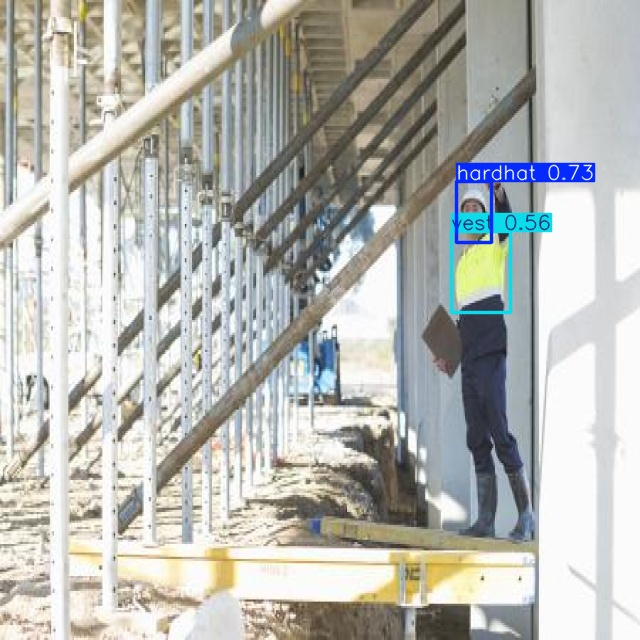

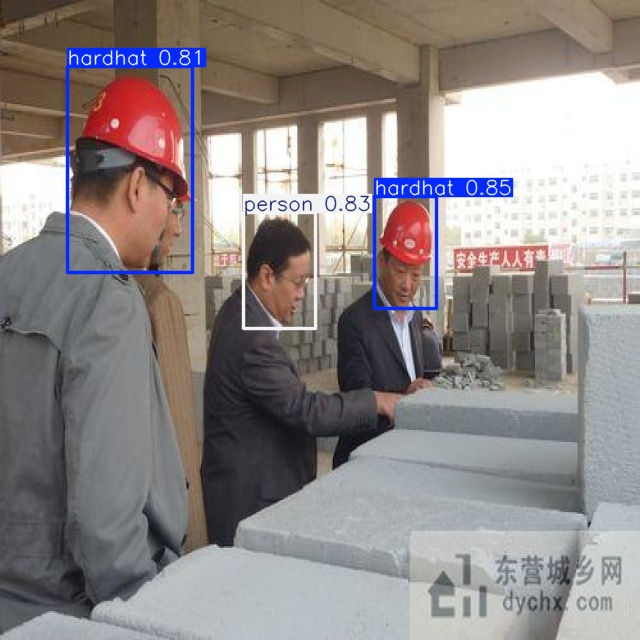

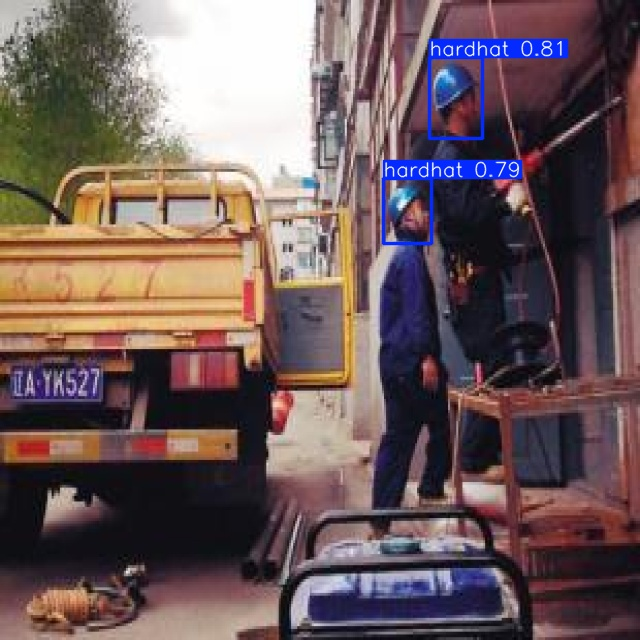